In [144]:

import numpy as np
import sys, os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
# from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
# from astropy.wcs import utils as asutils
# from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, gaussian
# from skimage.io import imread, imshow
# from skimage.feature import peak_local_max
# from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh
from matplotlib.backends.backend_pdf import PdfPages
from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ROI center 16, 0
ROI center in Galactic Coordintes = 16, 0
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 16.0 0.0 
CRPIX : 1800.0 720.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 3600  1440
Fits File loaded
Degrees per pixel: 0.005555555555555556 
Shape of Map in pixel number: 1440 X 3600
Degrees per pixel: 0.005555555555555556 
Peak intensity pixel location: (605, 1455)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (17.91122083, -0.63331454)>
Peak intensity value: 93.17355606087757
None
Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (605, 1455)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (17.91122083, -0.63331454)>
Peak intensity value: 93.17355606087757


(274.956409616554, -15.022356797490449)

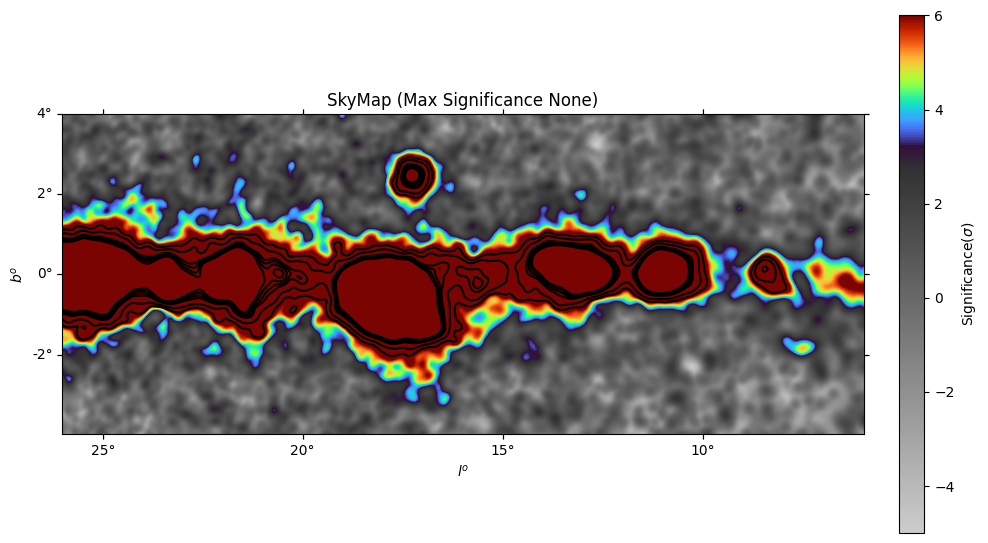

In [165]:
# Load the Simulation FITS file
filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
outdir = os.getcwd()+ '/galactic_plane_plots/'
if not os.path.exists(outdir):
    print("Creating output directory for plots")
    os.makedirs(outdir)



ra_center = 16
dec_center = 0
coord_sys = 'G'
xlength=10
ylength=4


# ra_center = 83.5
# dec_center = 22
# coord_sys = 'C'
# xlength=7
# ylength=7

save_pdf = False
if save_pdf:
    pdf = PdfPages(os.path.join(outdir, f'run-{ra_center}-{dec_center}-plots.pdf'))
print(f"ROI center {ra_center}, {dec_center}")

 

array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, ra_center, dec_center, xlength, ylength, coord_sys)
print(f'Shape of Map in pixel number: {ynum} X {xnum}')
print(f'Degrees per pixel: {pixel_size} ')
max_signif=find_peak(array, wcs)
print(max_signif)
fig, ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title=f'SkyMap (Max Significance {max_signif})', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
if save_pdf:
    pdf.savefig(fig)  
find_peak(array, wcs)
gal_to_cel(ra_center, dec_center)


Plotting contours [7, 9, 12, 13, 14, 15]


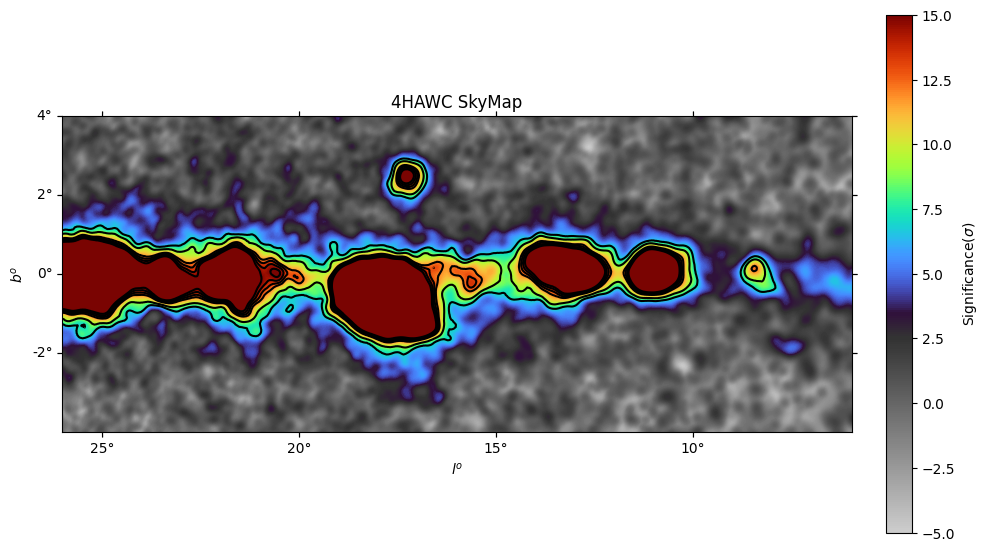

In [166]:
fig,ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=15, contour=True, title='4HAWC SkyMap',hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
if save_pdf:
    pdf.savefig(fig)  

Plotting contours [7, 9, 12, 13, 14, 15]


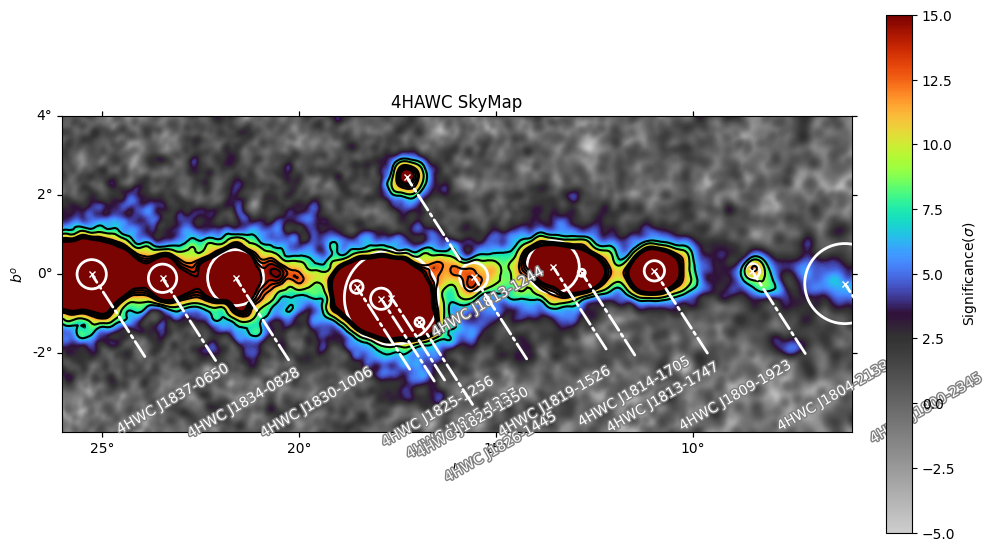

In [167]:
fig,ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=15, contour=True, title='4HAWC SkyMap',hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4hawc', '1lhaaaso'])
if save_pdf:
    pdf.savefig(fig)  

In [168]:
# Stop if there are no hotspots greater than 5 sigma
if np.max(array) < 5:
    print(f'Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)')
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
    ax.axis('off')  # Turn off axes
    text = f"Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
    plt.show()
    if save_pdf:
        pdf.savefig(fig)  
    exit
else:
    print(f'Algorithm will proceed. Significance Map has data greater than 4$\sigma$)')

Algorithm will proceed. Significance Map has data greater than 4$\sigma$)


In [169]:
print("Min significance in Loaded Map=",np.min(array))
print("Max significance in Loaded Map=",np.max(array))
if np.min(array) < -5:
    print("Image softly floored to -5 sigma")
    array = soft_floor(array, floor_min=-6, scale=1.0)

Min significance in Loaded Map= -4.91604526291297
Max significance in Loaded Map= 93.17355606087757


Significant deviation from Gaussian on positive side at:17,  3.66679
Signal (mean excess): 13.83331
Noise (background RMS): 1.54719
SNR: 8.94
Peak SNR: 60.22
2 sigma deviation from Gaussian fit on positive side 3.09438
3 sigma deviation from Gaussian fit on positive side 3.09438
Mask deviation value: 3.66679, Sigma of Gaussian fit: 1.54719
Signal-to-noise ratio (SNR) metric based on deviation from Gaussian fit: 2.3699696312113105
Signal-to-noise ratio (SNR) metric based blah: 8.94091823300518


(3.666794852918703, 3.0943812989237123, 4.641571948385568)

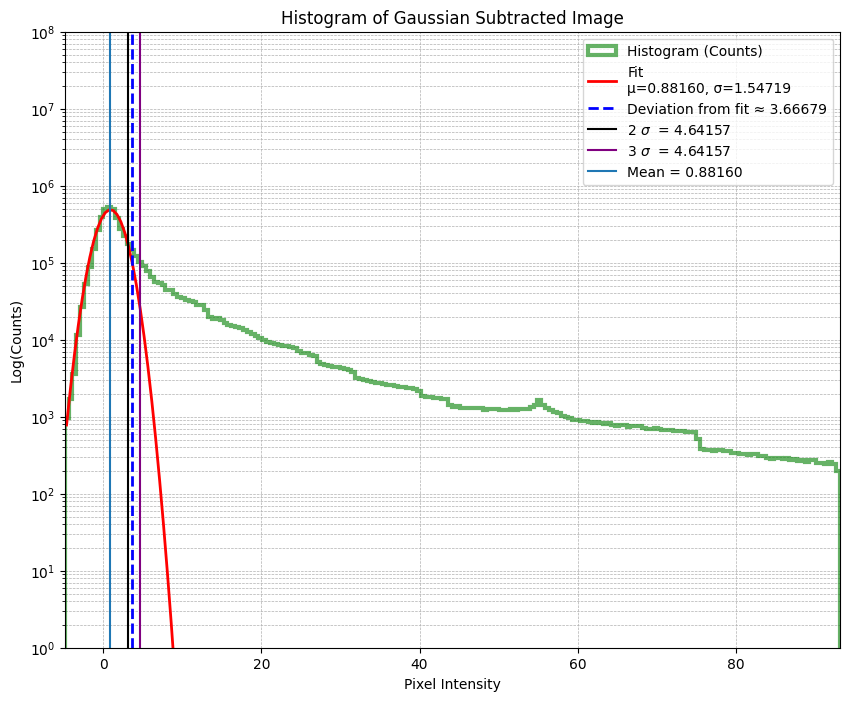

In [170]:
analyze_histogram(array, plot=True)

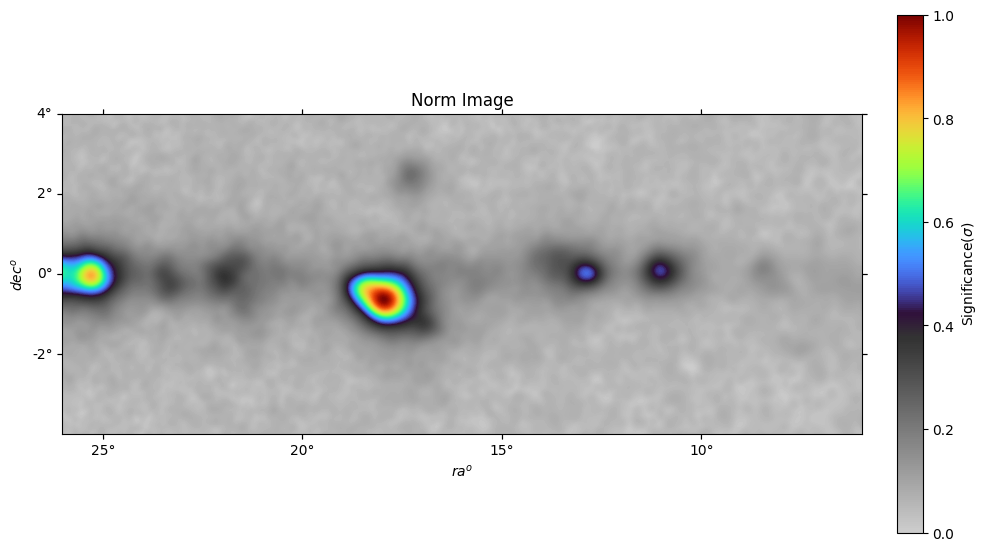

In [171]:
# #Normalize the image between 0 and 1 for analysis
image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
fig,ax=make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title='Norm Image', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6))
if save_pdf:
    pdf.savefig(fig) 


Pixel Size=0.0056
Number of pixels corresponding to 0.25 smear radius = 45.00
Estimated background RMS: 0.008793270891874379
Number of point source blobs= 12
Blob Intensity 89.25809521779851, Coords (276.48512871057864 deg, -13.619970438769018 deg), Radius 43.199999999999996, Pixel Radius 0.24
Blob Intensity 73.4305307188036, Coords (279.3631838536773 deg, -6.860418207270729 deg), Radius 26.999999999999996, Pixel Radius 0.15
Blob Intensity 42.32429018639595, Coords (273.3824946805361 deg, -17.78085275143499 deg), Radius 26.999999999999996, Pixel Radius 0.15
Blob Intensity 37.74929057376288, Coords (272.39829991822796 deg, -19.341417733959933 deg), Radius 43.199999999999996, Pixel Radius 0.24
Blob Intensity 63.654457200279516, Coords (276.46921952377346 deg, -12.958647145183877 deg), Radius 26.999999999999996, Pixel Radius 0.15
Blob Intensity 31.01697156901089, Coords (277.895692324343 deg, -9.801912474571406 deg), Radius 26.999999999999996, Pixel Radius 0.15
Blob Intensity 27.187224635

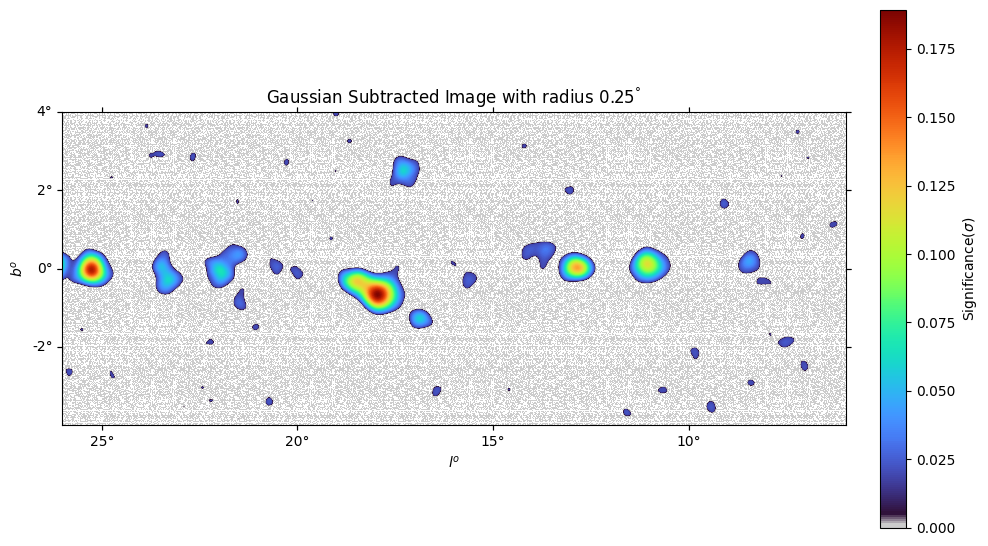

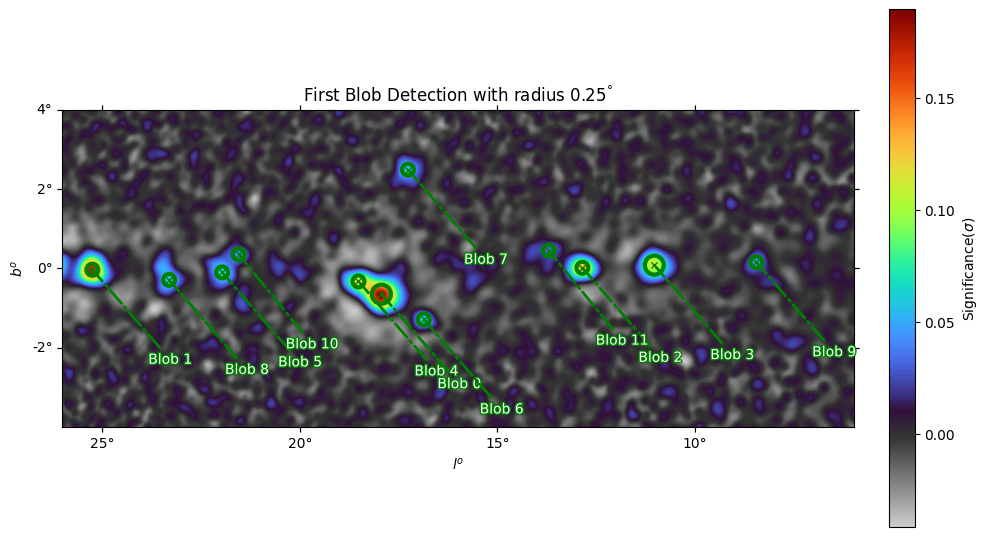

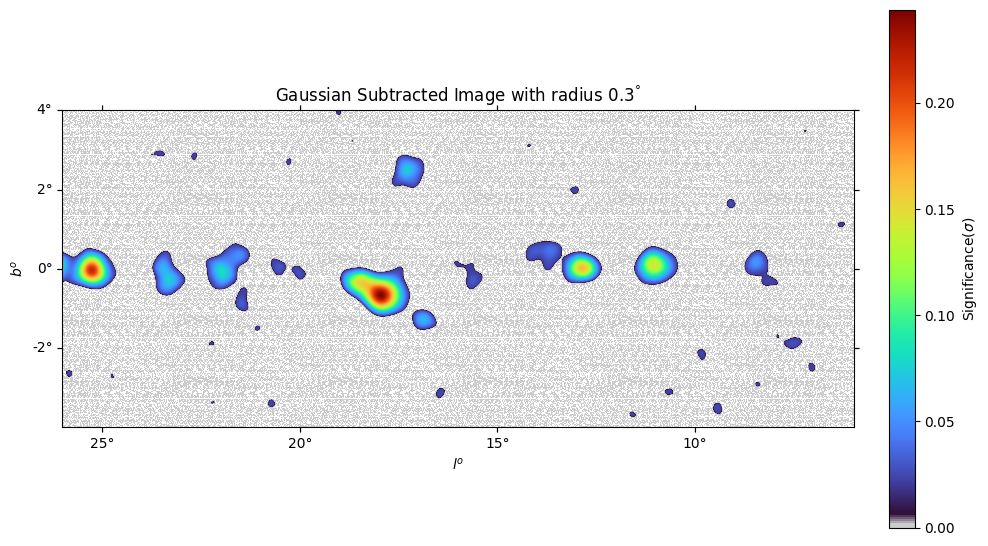

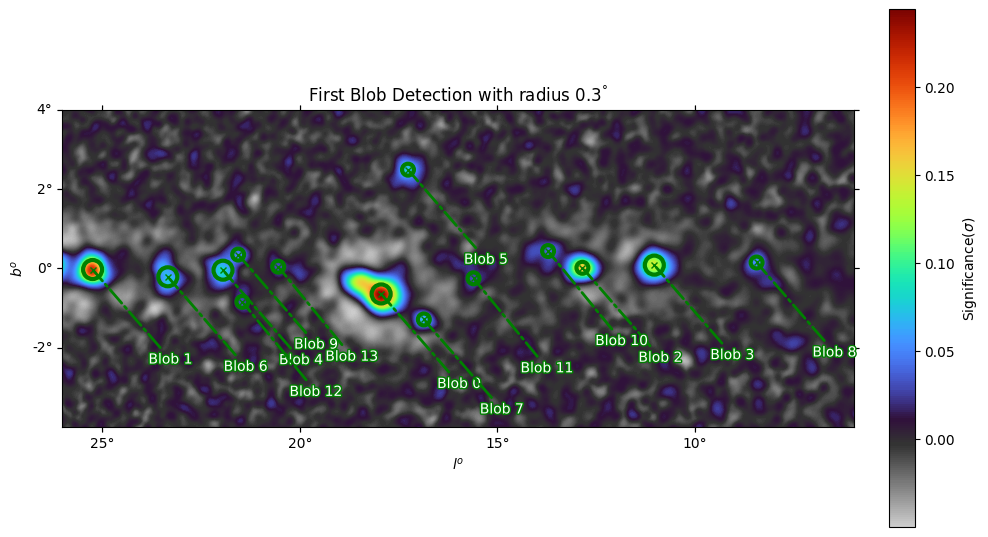

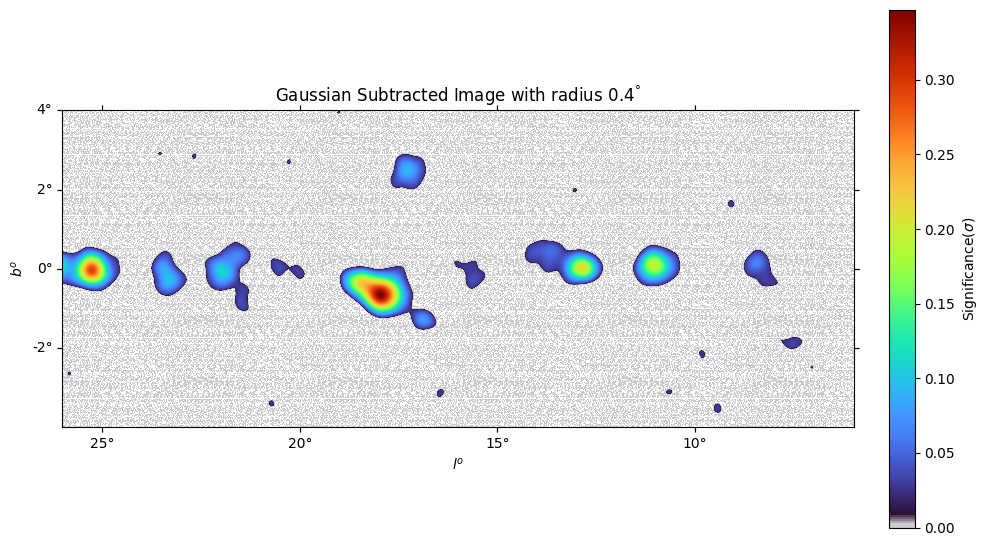

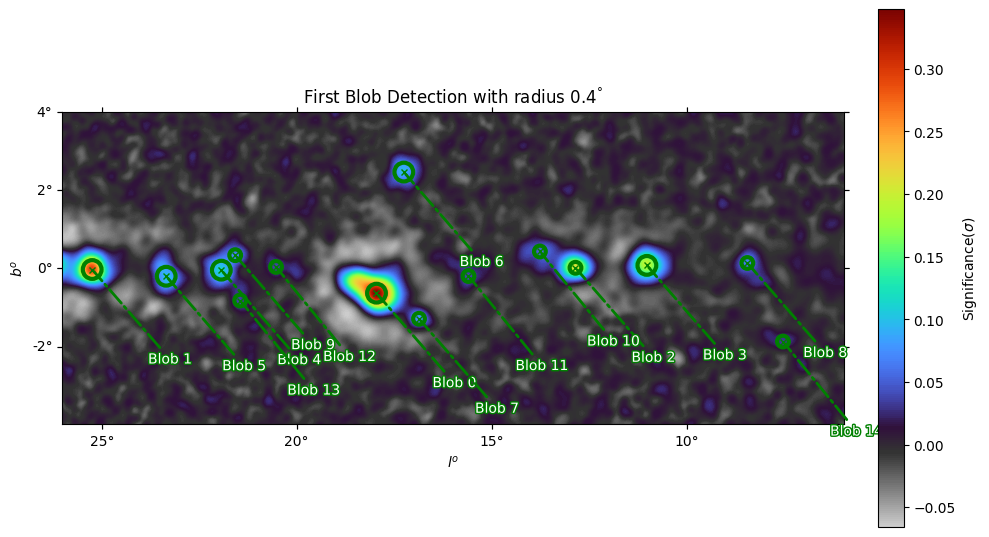

In [172]:
from scipy.spatial.distance import cdist

all_ps_blobs = []
all_ext_blobs = []
all_pscoord_blobs = []
all_extcoord_blobs = []
all_psradius_blobs = []
all_extradius_blobs = []
# for radius in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
for radius in [0.25, 0.3,  0.4]:
    smear_radius=radius #PSF of the dec band
    print(f"Pixel Size={pixel_size:.4f}")
    print(f"Number of pixels corresponding to {smear_radius:.2f} smear radius = {smear_radius/pixel_size:.2f}")
    dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
    import scipy.ndimage as ndi
    dog_low_noise = ndi.gaussian_filter(dog_image, sigma=1.0)

    from astropy.stats import sigma_clip
    import numpy as np

    def estimate_background_sigma(image, sigma=3, maxiters=5):
        clipped = sigma_clip(image, sigma=sigma, maxiters=maxiters)
        return np.std(clipped.data[~clipped.mask])

    sigma_resid = estimate_background_sigma(dog_image)
    print("Estimated background RMS:", sigma_resid)

    dog_final = np.where(dog_low_noise > 2 * sigma_resid, dog_low_noise, 0)
    # mask_deviation_value, deviation_2sig, deviation_3sig= analyze_histogram(dog_final, plot=True)
    fig,ax=make_plots(dog_final, wcs, pixel_size, coordsys='G', threshold=0.0000005,vmin=np.min(dog_final), vmax=np.max(dog_final), title=f'Gaussian Subtracted Image with radius {smear_radius}$^\degree$', cmap='ult')

    threshold_val = 0.01
    # ps_blobs = blob_dog(dog_final, min_sigma=0.1/pixel_size, max_sigma=smear_radius/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
    ps_blobs = blob_dog(dog_final, min_sigma=0.15/pixel_size,  max_sigma=0.8/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.7)
    print("Number of point source blobs=",len(ps_blobs))
    blobs_dict = {
        'psblobs': ps_blobs,
    }
    fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=None,blobs=blobs_dict,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'First Blob Detection with radius {smear_radius}$^\degree$', cmap='ult', labels=['4haawc'])
    ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, array,5 , wcs, pixel_size)
    if len(ps_filtered_blobs) > 0:
        all_ps_blobs.append(ps_filtered_blobs)
        all_pscoord_blobs.append(ps_filtered_coords)
        all_psradius_blobs.append(ps_filtered_radius)

Combined point sources: 40 → After removing overlaps: 15


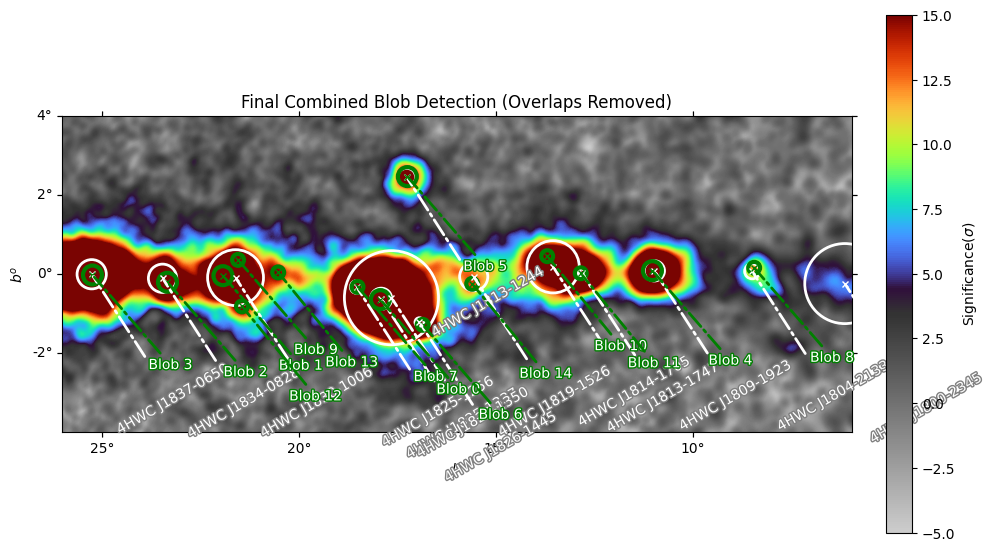

In [173]:
if len(all_ps_blobs) > 0:
    combined_ps_blobs = np.vstack(all_ps_blobs)
    # Flatten the list of lists of SkyCoord objects
    combined_pscoord_blobs = [coord for sublist in all_pscoord_blobs for coord in sublist]
    # Flatten the list of lists of radii values
    combined_psradius_blobs = [radius for sublist in all_psradius_blobs for radius in sublist]
else:
    combined_ps_blobs = np.array([]).reshape(0, 3)
    combined_pscoord_blobs = []
    combined_psradius_blobs = []

def remove_overlapping_blobs(blobs, coords, radii, overlap_threshold=0.5):
    """
    Remove overlapping blobs, keeping the one with larger radius.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Each row: [y, x, radius]
    coords : list of SkyCoord objects
        Corresponding sky coordinates
    radii : list of float
        Corresponding radii values
    overlap_threshold : float
        Fraction of overlap to consider blobs as duplicates
    """
    if len(blobs) == 0:
        return blobs, coords, radii
    
    # Sort by radius (descending) to keep larger blobs
    sorted_indices = np.argsort(blobs[:, 2])[::-1]
    sorted_blobs = blobs[sorted_indices]
    sorted_coords = [coords[i] for i in sorted_indices]  # Reorder list
    sorted_radii = [radii[i] for i in sorted_indices]  # Reorder list
    
    keep_mask = np.ones(len(sorted_blobs), dtype=bool)
    
    for i in range(len(sorted_blobs)):
        if not keep_mask[i]:
            continue
        
        # Calculate distance to all other blobs
        distances = np.sqrt((sorted_blobs[i, 0] - sorted_blobs[:, 0])**2 + 
                           (sorted_blobs[i, 1] - sorted_blobs[:, 1])**2)
        
        # Check for overlap
        radii_sum = sorted_blobs[i, 2] + sorted_blobs[:, 2]
        overlap = (radii_sum - distances) / np.minimum(sorted_blobs[i, 2], sorted_blobs[:, 2])
        
        # Mark overlapping blobs (except itself) for removal
        keep_mask[overlap > overlap_threshold] = False
        keep_mask[i] = True  # Keep the current blob
    
    # Filter all arrays/lists by keep_mask
    filtered_blobs = sorted_blobs[keep_mask]
    filtered_coords = [coord for i, coord in enumerate(sorted_coords) if keep_mask[i]]
    filtered_radii = [radius for i, radius in enumerate(sorted_radii) if keep_mask[i]]
    
    return filtered_blobs, filtered_coords, filtered_radii

# Remove overlaps
final_ps_blobs, final_pscoords_blobs, final_psradius_blobs = remove_overlapping_blobs(
    combined_ps_blobs, combined_pscoord_blobs, combined_psradius_blobs)

print(f"Combined point sources: {len(combined_ps_blobs)} → After removing overlaps: {len(final_ps_blobs)}")

# Plot final results (only if there are blobs to plot)
if len(final_ps_blobs) > 0 :
    blobs_dict = {
        'psblobs': final_ps_blobs,
    }
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, 
                         title='Final Combined Blob Detection (Overlaps Removed)', cmap='ult', labels=['4hawc'])
    if save_pdf:
        pdf.savefig(fig)
else:
    print("No blobs found to plot")

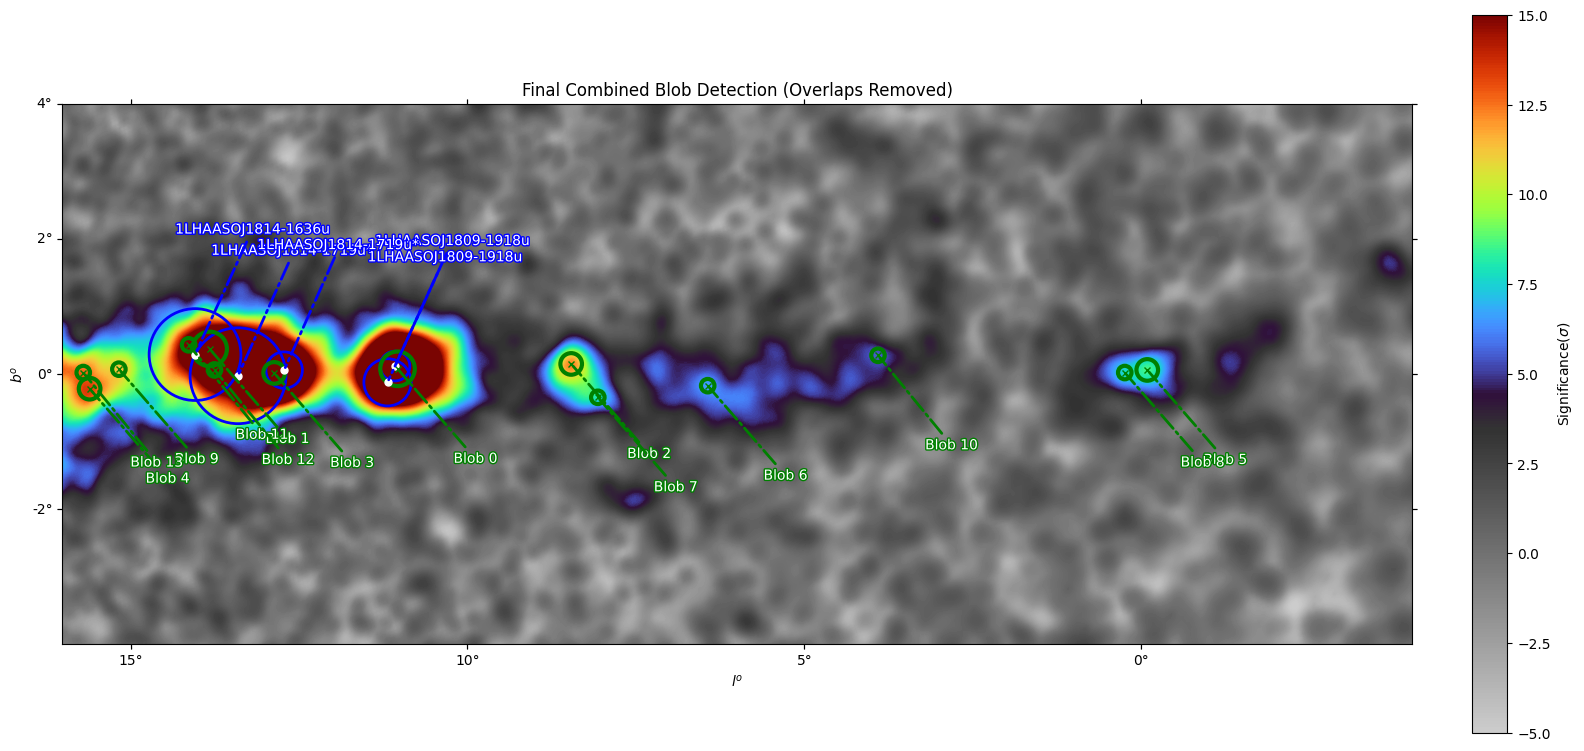

In [155]:
fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict,  title='Final Combined Blob Detection (Overlaps Removed)', cmap='ult', labels=['1lhaaso'], figsize=(16, 8))

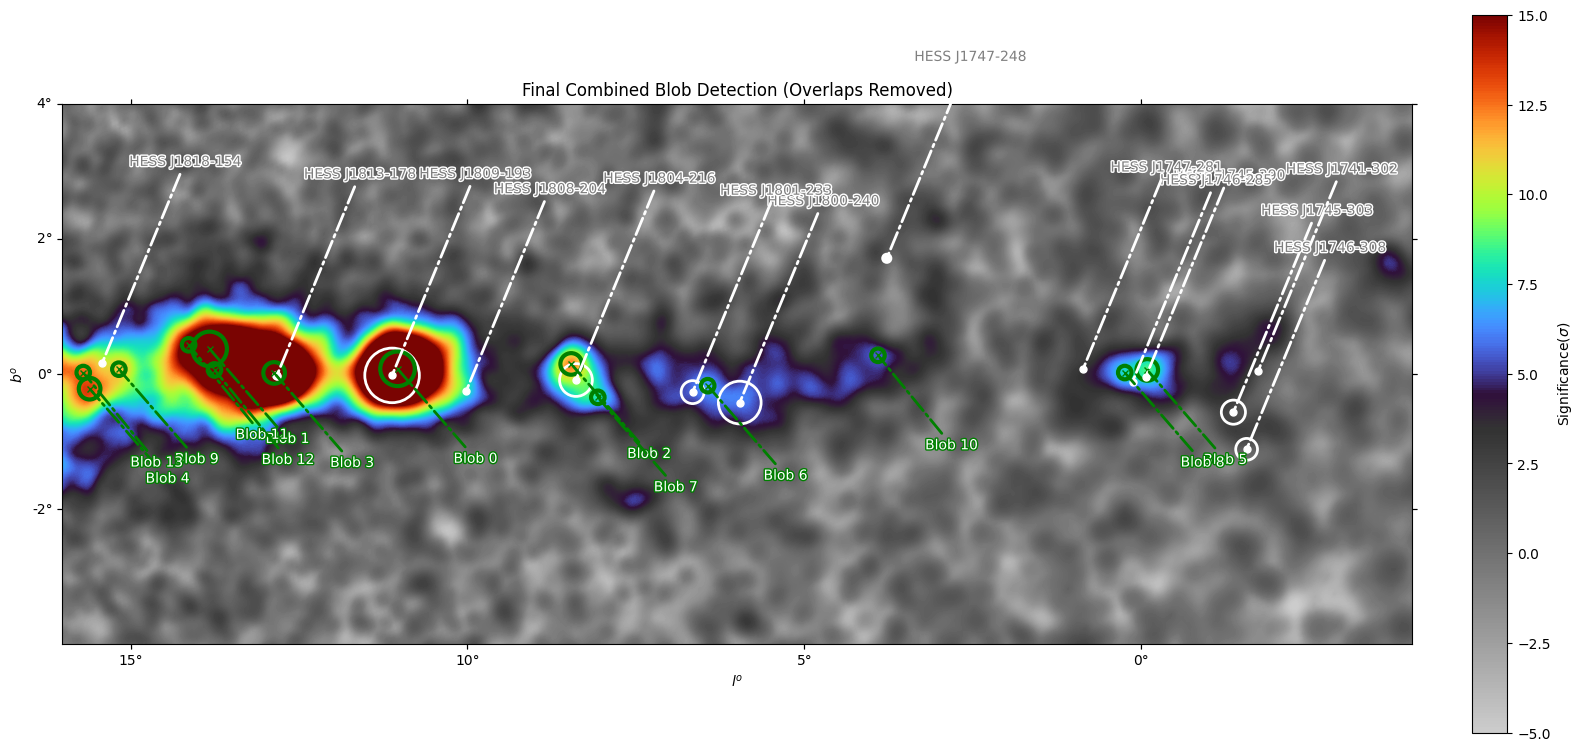

In [156]:
fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict,  title='Final Combined Blob Detection (Overlaps Removed)', cmap='ult', labels=['hgps'], figsize=(16, 8))

In [111]:
# import re

# def extract_value(s):
#     # remove < or > signs
#     s = s.replace("<", "").replace(">", "")
#     # extract the first floating-point number
#     match = re.search(r"\d+\.\d+", s)
#     return float(match.group()) if match else None

# val = extract_value(df['r_39'][2])
# print(val)

0.17


In [134]:
# def plot_1lhaaso_wcda(ax, wcs, npix):
#     for i in range(len(df)):
#         if df['RA_2000'][i] != '':
#             if df['Components'][i]=='WCDA':
#                 # print(f"Plotting {df['Source name'][i]} with RA={df['RA_2000'][i]} and Dec={df['Dec_2000'][i]}")
#                 # if df['Source name'] != 'None':
#                 coord2 = SkyCoord(ra=float(df['RA_2000'][i])*u.deg, dec=float(df['Dec_2000'][i])*u.deg)
#                 coord_gal = coord2.galactic
#                 pixelcoord = astropy_utils.skycoord_to_pixel(coord_gal, wcs)
#                 ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='white')
#                 ax.annotate(df['Source name'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', xytext=(50, -90), 
#                 textcoords='offset points', arrowprops=dict(arrowstyle="-",color='cyan', linewidth=2, 
#                 linestyle='-.'), color='white', rotation=30, ha='right', va='center' ,
#                 path_effects=[pe.withStroke(linewidth=2, foreground="cyan")])
#                 val = extract_value(df['r_39'][2])
#                 try:
#                     hawcext = plt.Circle((pixelcoord[0], pixelcoord[1]), float(val)/npix, color='cyan', linewidth=2, fill=False, linestyle='-')
#                     ax.add_patch(hawcext)
#                 except:
#                     pass

In [43]:
# from scipy.spatial.distance import cdist

# all_ps_blobs = []
# all_ext_blobs = []
# all_pscoord_blobs = []
# all_extcoord_blobs = []
# all_psradius_blobs = []
# all_extradius_blobs = []

In [ ]:
# for radius in [0.2, 0.3, 0.4, 0.5]:
#     smear_radius=radius #PSF of the dec band
#     print(f"Pixel Size={pixel_size:.4f}")
#     print(f"Number of pixels corresponding to {smear_radius:.2f} smear radius = {smear_radius/pixel_size:.2f}")
#     dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
#     fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.0000005,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'Gaussian Subtracted Image with radius {smear_radius}$^\degree$', cmap='ult')
#     # mask_deviation_value, deviation_2sig, deviation_3sig= analyze_histogram(dog_image, plot=True)
#     # threshold_val = 0.01
#     # ps_blobs = blob_dog(dog_image, min_sigma=0.1/pixel_size, max_sigma=smear_radius/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
#     # print("Number of point source blobs=",len(ps_blobs))
#     # ext_blobs = blob_dog(dog_image, min_sigma=1.1*smear_radius/pixel_size, max_sigma=0.8/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
#     # print("Number of ext source blobs=",len(ext_blobs))

Pixel Size=0.0056
Number of pixels corresponding to 0.20 smear radius = 36.00
Significant deviation from Gaussian on positive side at:95,  0.03508
Signal (mean excess): 0.05502
Noise (background RMS): 0.01405
SNR: 3.91
Peak SNR: 10.73
2 sigma deviation from Gaussian fit on positive side 0.02811
3 sigma deviation from Gaussian fit on positive side 0.02811
Mask deviation value: 0.03508, Sigma of Gaussian fit: 0.01405
Signal-to-noise ratio (SNR) metric based on deviation from Gaussian fit: 2.495974925263109
Signal-to-noise ratio (SNR) metric based blah: 3.9148476967514387
Number of point source blobs= 67
Number of ext source blobs= 10
Number of point source blobs= 67
Number of ext source blobs= 10
Number of point source blob 1st filter= 11
Number of ext source blobs= 3
No of ps 2nd filter=  3
No of ext =  3
Pixel Size=0.0056
Number of pixels corresponding to 0.30 smear radius = 54.00
Significant deviation from Gaussian on positive side at:77,  0.04273
Signal (mean excess): 0.07716
Noise (

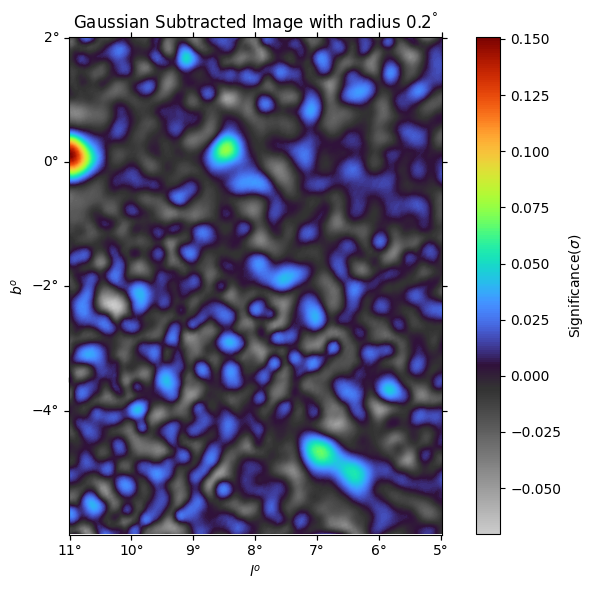

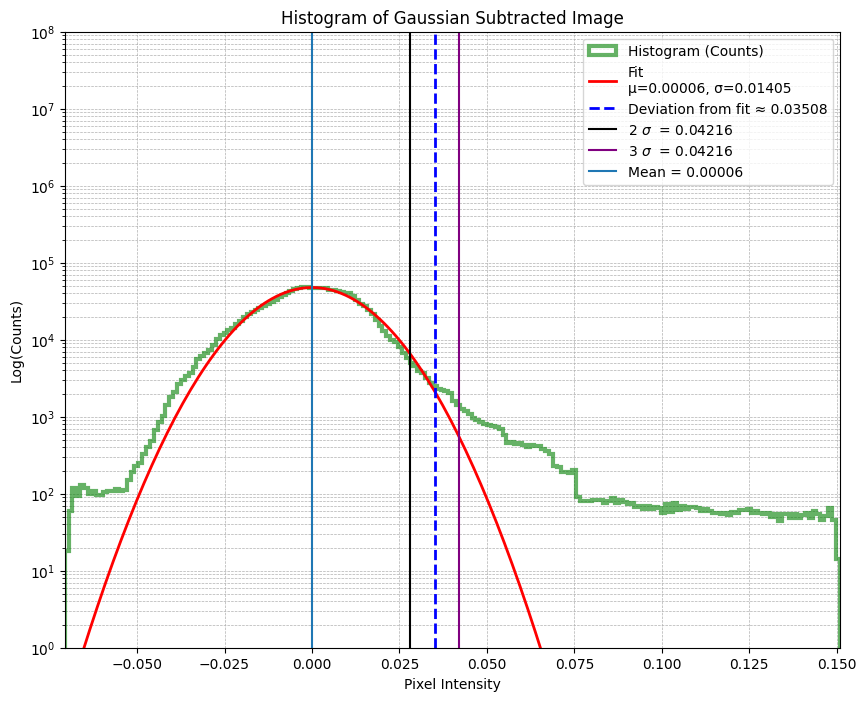

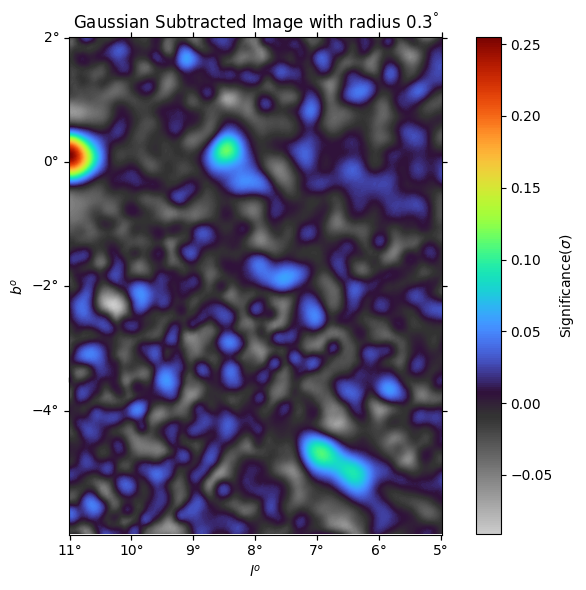

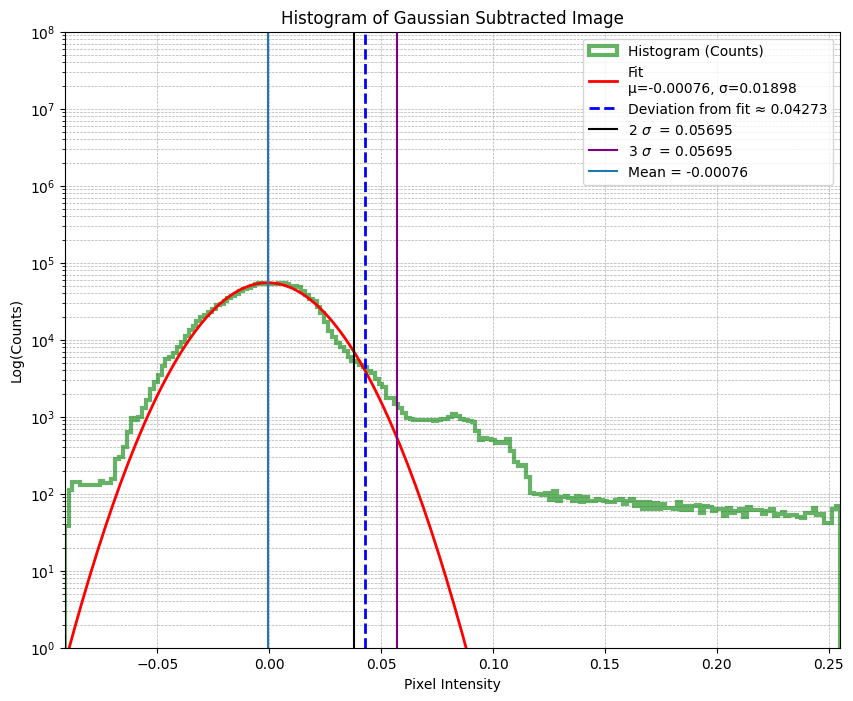

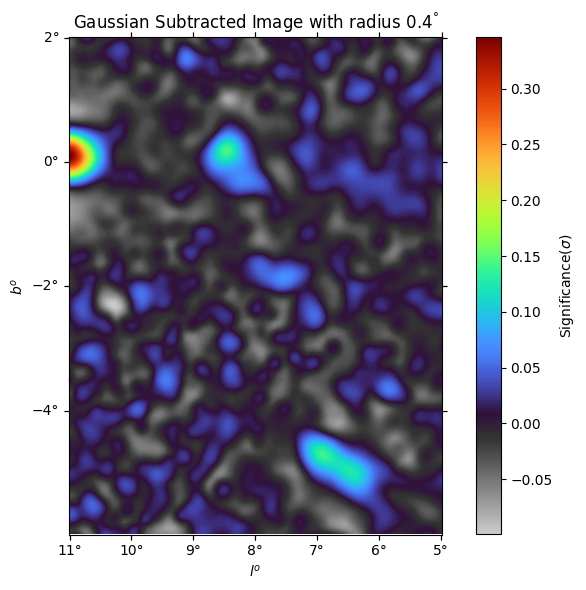

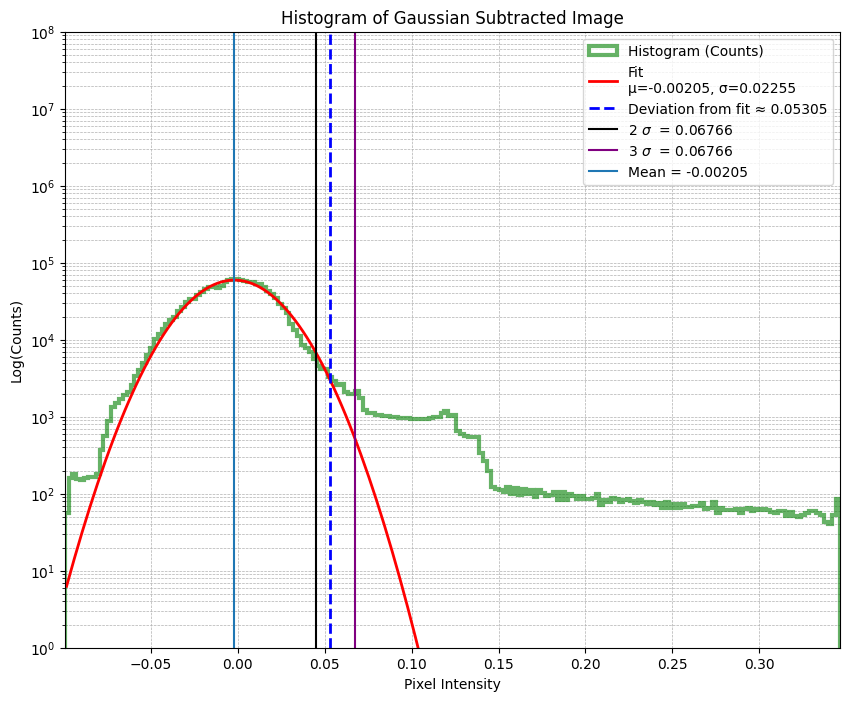

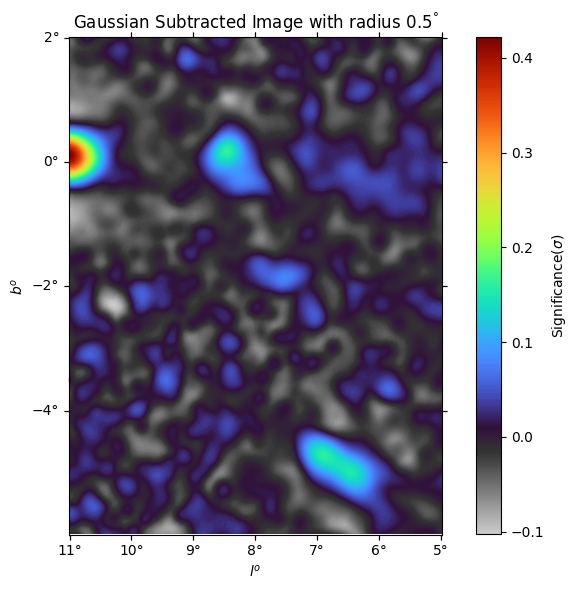

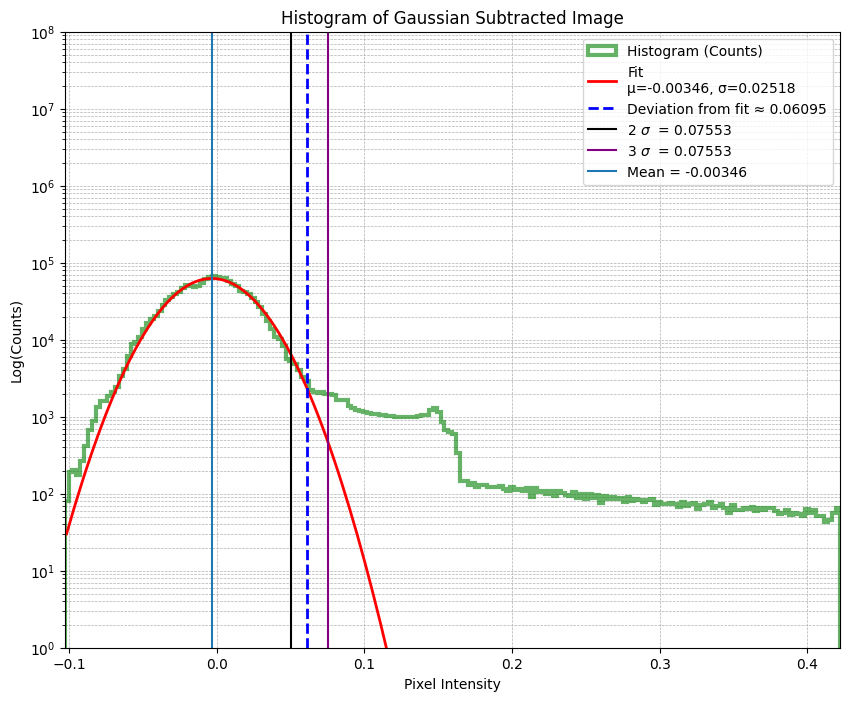

In [13]:

for radius in [0.2, 0.3, 0.4, 0.5]:
# Find the Difference of Gaussian (DoG) Image
    smear_radius=radius #PSF of the dec band
    print(f"Pixel Size={pixel_size:.4f}")
    print(f"Number of pixels corresponding to {smear_radius:.2f} smear radius = {smear_radius/pixel_size:.2f}")
    dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
    # smoothed = dog_image
    # smoothed = smoothed[::4, ::4]
    # x = np.arange(smoothed.shape[1])
    # y = np.arange(smoothed.shape[0])
    # X, Y = np.meshgrid(x, y)

    # coordinates = peak_local_max(smoothed, min_distance=5, threshold_rel=0.1)
    # peak_x = coordinates[:, 1]
    # peak_y = coordinates[:, 0]
    # peak_z = smoothed[peak_y, peak_x]


    # fig = plt.figure(figsize=(6, 5))#, dpi=80)
    # ax = fig.add_subplot(111, projection='3d')
    # surface = ax.plot_surface(X, Y, smoothed, cmap='plasma', edgecolor='none')
    # peaks_plot = ax.scatter(peak_x, peak_y, peak_z, c='black', s=50, label='Peaks')
    # ax.set_xlabel('X')
    # ax.set_ylabel('Y')
    # ax.set_zlabel('Intensity')
    # ax.set_title('3D Surface Histogram of Significance')
    # def update(frame):
    #     ax.view_init(elev=30, azim=frame)
    #     return fig,

    # ani = animation.FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=50)
    # ani.save(f'gaussian_surface_rotation-{smear_radius}.gif', writer='pillow')
    fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.0000005,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'Gaussian Subtracted Image with radius {smear_radius}$^\degree$', cmap='ult')
    # if save_pdf:
    #     pdf.savefig(fig) 
    norm_dog_image = (dog_image-np.min(dog_image))/(np.max(dog_image)-np.min(dog_image))
    # fig,ax=make_plots(norm_dog_image, wcs, pixel_size, vmin=np.min(norm_dog_image), vmax=np.max(norm_dog_image), hotspots=None,threshold=0.2,coordsys='G',title=f'Low Frequeny Smoothed Image', cmap='ult', labels=['4haawc'])
    # if save_pdf:
    #     pdf.savefig(fig) 
    lowfreq_image=norm_image-norm_dog_image
    norm_lowfreq_image = (lowfreq_image-np.min(lowfreq_image))/(np.max(lowfreq_image)-np.min(lowfreq_image))
    norm_lowfreq_image = gaussian(norm_lowfreq_image, sigma=0.5/pixel_size)
    # fig,ax=make_plots(norm_lowfreq_image, wcs, pixel_size, vmin=np.min(norm_lowfreq_image), vmax=np.max(norm_lowfreq_image), hotspots=None,threshold=0.2,coordsys='G',title=f'Low Frequeny Smoothed Image', cmap='ult', labels=['4haawc'])
    # if save_pdf:
    #     pdf.savefig(fig) 
    mask_deviation_value, deviation_2sig, deviation_3sig= analyze_histogram(dog_image, plot=True)
    # from skimage.feature import peak_local_max
    # coords = peak_local_max(dog_image, threshold_abs=deviation_2sig)
    # fig = plt.figure(figsize=(10, 6))
    # ax = fig.add_subplot(1, 1, 1, projection=wcs)
    # plt.imshow(norm_dog_image)
    # plt.scatter(coords[:,1], coords[:,0], c='r')
    # # Count pixels above the threshold
    # num_pixels_above = np.sum(dog_image > mask_deviation_value)
    # print(f"Number of pixels above {mask_deviation_value}: {num_pixels_above}")

    # Optional: fraction of total image
    # fraction_above = num_pixels_above / dog_image.size
    # print(f"Fraction of image above threshold: {fraction_above:.4f}")

    # plt.imshow(dog_image, cmap='gray')
    # plt.scatter(*np.where(dog_image > mask_deviation_value)[::-1], c='r', s=10)
    # plt.title(f"Pixels above {mask_deviation_value}")
    # plt.show()
    # Find the blobs from the DoG image
    #  mask_deviation_value, deviation_3sig
    threshold_val = 0.01
    ps_blobs = blob_dog(dog_image, min_sigma=0.1/pixel_size, max_sigma=smear_radius/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
    print("Number of point source blobs=",len(ps_blobs))
    ext_blobs = blob_dog(dog_image, min_sigma=1.1*smear_radius/pixel_size, max_sigma=0.8/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
    print("Number of ext source blobs=",len(ext_blobs))


    ps_blobs = ps_blobs[ps_blobs[:, 2] < smear_radius/pixel_size]
    ext_blobs = ext_blobs[ext_blobs[:, 2] > smear_radius/pixel_size]
    print("Number of point source blobs=",len(ps_blobs))
    print("Number of ext source blobs=",len(ext_blobs))
    # DoG Image Intensity Filtering
    # deviation2 = 0.00001
    # deviation2 = deviation_3sig
    intensity_min=deviation_3sig/3 * 2.5
    # intensity_min=0.00001

    ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, dog_image, intensity_min, wcs, pixel_size)
    print("Number of point source blob 1st filter=",len(ps_filtered_blobs))

    ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, dog_image, intensity_min, wcs, pixel_size)
    print("Number of ext source blobs=",len(ext_filtered_blobs))
    blobs_dict = {
        'psblobs': ps_filtered_blobs,
        'extblobs': ext_filtered_blobs,
    }
    # fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=None,blobs=blobs_dict,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'First Blob Detection Pass 1', cmap='ult', labels=['4haawc'])
    # if save_pdf:
    #     pdf.savefig(fig) 
    # Input Significance Image Intensity Filtering
    ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, pixel_size)
    ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 5, wcs, pixel_size)
    print("No of ps 2nd filter= ", len(ps_filtered_blobs2))
    print("No of ext = ", len(ext_filtered_blobs3))
    blobs_dict = {
        'psblobs': ps_filtered_blobs2,
        'extblobs': ext_filtered_blobs3,
    }
    # fig,ax=make_plots(array, wcs, pixel_size,coordsys='G', blobs=blobs_dict, title=f'First Blob Detection Pass 2', cmap='ult')

    # if save_pdf:
    #     pdf.savefig(fig)
    if len(ps_filtered_blobs2) > 0:
        all_ps_blobs.append(ps_filtered_blobs2)
        all_pscoord_blobs.append(ps_filtered_coords2)
        all_psradius_blobs.append(ps_filtered_radius2)
    if len(ext_filtered_blobs3) > 0:
        all_ext_blobs.append(ext_filtered_blobs3)
        all_extcoord_blobs.append(ext_filtered_coords3)
        all_extradius_blobs.append(ext_filtered_radius3)


Combined point sources: 9 → After removing overlaps: 3
Combined extended sources: 9 → After removing overlaps: 2


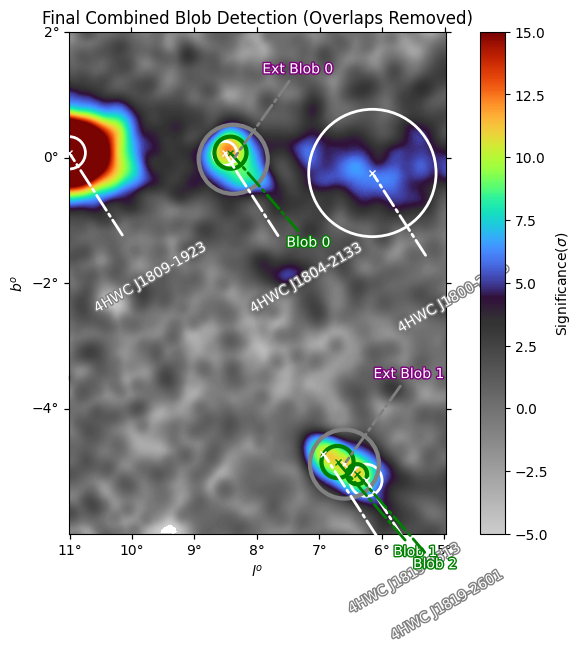

In [14]:
if len(all_ps_blobs) > 0:
    combined_ps_blobs = np.vstack(all_ps_blobs)
    # Flatten the list of lists of SkyCoord objects
    combined_pscoord_blobs = [coord for sublist in all_pscoord_blobs for coord in sublist]
    # Flatten the list of lists of radii values
    combined_psradius_blobs = [radius for sublist in all_psradius_blobs for radius in sublist]
else:
    combined_ps_blobs = np.array([]).reshape(0, 3)
    combined_pscoord_blobs = []
    combined_psradius_blobs = []

if len(all_ext_blobs) > 0:
    combined_ext_blobs = np.vstack(all_ext_blobs)
    # Flatten the list of lists of SkyCoord objects
    combined_extcoord_blobs = [coord for sublist in all_extcoord_blobs for coord in sublist]
    # Flatten the list of lists of radii values
    combined_extradius_blobs = [radius for sublist in all_extradius_blobs for radius in sublist]
else:
    combined_ext_blobs = np.array([]).reshape(0, 3)
    combined_extcoord_blobs = []
    combined_extradius_blobs = []

def remove_overlapping_blobs(blobs, coords, radii, overlap_threshold=0.5):
    """
    Remove overlapping blobs, keeping the one with larger radius.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Each row: [y, x, radius]
    coords : list of SkyCoord objects
        Corresponding sky coordinates
    radii : list of float
        Corresponding radii values
    overlap_threshold : float
        Fraction of overlap to consider blobs as duplicates
    """
    if len(blobs) == 0:
        return blobs, coords, radii
    
    # Sort by radius (descending) to keep larger blobs
    sorted_indices = np.argsort(blobs[:, 2])[::-1]
    sorted_blobs = blobs[sorted_indices]
    sorted_coords = [coords[i] for i in sorted_indices]  # Reorder list
    sorted_radii = [radii[i] for i in sorted_indices]  # Reorder list
    
    keep_mask = np.ones(len(sorted_blobs), dtype=bool)
    
    for i in range(len(sorted_blobs)):
        if not keep_mask[i]:
            continue
        
        # Calculate distance to all other blobs
        distances = np.sqrt((sorted_blobs[i, 0] - sorted_blobs[:, 0])**2 + 
                           (sorted_blobs[i, 1] - sorted_blobs[:, 1])**2)
        
        # Check for overlap
        radii_sum = sorted_blobs[i, 2] + sorted_blobs[:, 2]
        overlap = (radii_sum - distances) / np.minimum(sorted_blobs[i, 2], sorted_blobs[:, 2])
        
        # Mark overlapping blobs (except itself) for removal
        keep_mask[overlap > overlap_threshold] = False
        keep_mask[i] = True  # Keep the current blob
    
    # Filter all arrays/lists by keep_mask
    filtered_blobs = sorted_blobs[keep_mask]
    filtered_coords = [coord for i, coord in enumerate(sorted_coords) if keep_mask[i]]
    filtered_radii = [radius for i, radius in enumerate(sorted_radii) if keep_mask[i]]
    
    return filtered_blobs, filtered_coords, filtered_radii

# Remove overlaps
final_ps_blobs, final_pscoords_blobs, final_psradius_blobs = remove_overlapping_blobs(
    combined_ps_blobs, combined_pscoord_blobs, combined_psradius_blobs)
final_ext_blobs, final_extcoords_blobs, final_extradius_blobs = remove_overlapping_blobs(
    combined_ext_blobs, combined_extcoord_blobs, combined_extradius_blobs)

print(f"Combined point sources: {len(combined_ps_blobs)} → After removing overlaps: {len(final_ps_blobs)}")
print(f"Combined extended sources: {len(combined_ext_blobs)} → After removing overlaps: {len(final_ext_blobs)}")

# Plot final results (only if there are blobs to plot)
if len(final_ps_blobs) > 0 or len(final_ext_blobs) > 0:
    blobs_dict = {
        'psblobs': final_ps_blobs,
        'extblobs': final_ext_blobs,
    }
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, 
                         title='Final Combined Blob Detection (Overlaps Removed)', cmap='ult', labels=['4hawc'])
    if save_pdf:
        pdf.savefig(fig)
else:
    print("No blobs found to plot")

After removing PS-EXT overlaps:
  Point sources: 0
  Extended sources: 2


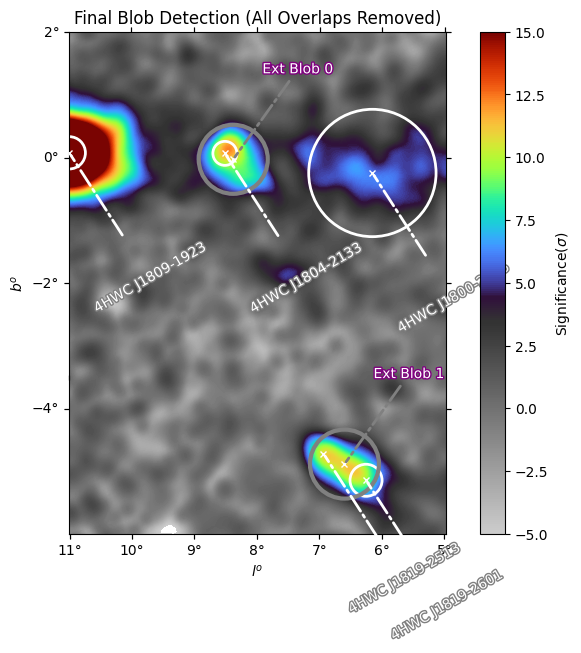

In [16]:
def remove_cross_overlap(ps_blobs, ps_coords, ps_radii, ext_blobs, ext_coords, ext_radii, overlap_threshold=0.5):
    """
    Remove overlaps between point source and extended source blobs.
    Priority: Keep extended sources, remove overlapping point sources.
    
    Parameters:
    -----------
    ps_blobs : array of shape (n_blobs, 3)
        Point source blobs [y, x, radius]
    ps_coords : list of SkyCoord objects
        Point source sky coordinates
    ps_radii : list of float
        Point source radii values
    ext_blobs : array of shape (n_blobs, 3)
        Extended source blobs [y, x, radius]
    ext_coords : list of SkyCoord objects
        Extended source sky coordinates
    ext_radii : list of float
        Extended source radii values
    overlap_threshold : float
        Fraction of overlap to consider blobs as duplicates
    
    Returns:
    --------
    filtered_ps_blobs : array
        Point source blobs with overlaps removed
    filtered_ps_coords : list
        Point source coords with overlaps removed
    filtered_ps_radii : list
        Point source radii with overlaps removed
    ext_blobs : array
        Extended source blobs (unchanged)
    ext_coords : list
        Extended source coords (unchanged)
    ext_radii : list
        Extended source radii (unchanged)
    """
    if len(ps_blobs) == 0 or len(ext_blobs) == 0:
        return ps_blobs, ps_coords, ps_radii, ext_blobs, ext_coords, ext_radii
    
    keep_mask = np.ones(len(ps_blobs), dtype=bool)
    
    for i in range(len(ps_blobs)):
        # Calculate distance to all extended source blobs
        distances = np.sqrt((ps_blobs[i, 0] - ext_blobs[:, 0])**2 + 
                           (ps_blobs[i, 1] - ext_blobs[:, 1])**2)
        
        # Check for overlap with any extended source
        radii_sum = ps_blobs[i, 2] + ext_blobs[:, 2]
        overlap = (radii_sum - distances) / np.minimum(ps_blobs[i, 2], ext_blobs[:, 2])
        
        # If this point source overlaps with any extended source, remove it
        if np.any(overlap > overlap_threshold):
            keep_mask[i] = False
    
    # Filter point source arrays/lists by keep_mask
    filtered_ps_blobs = ps_blobs[keep_mask]
    filtered_ps_coords = [coord for i, coord in enumerate(ps_coords) if keep_mask[i]]
    filtered_ps_radii = [radius for i, radius in enumerate(ps_radii) if keep_mask[i]]
    
    return filtered_ps_blobs, filtered_ps_coords, filtered_ps_radii, ext_blobs, ext_coords, ext_radii

# Remove overlaps between point sources and extended sources
final_ps_blobs, final_pscoords_blobs, final_psradius_blobs, final_ext_blobs, final_extcoords_blobs, final_extradius_blobs = remove_cross_overlap(
    final_ps_blobs, final_pscoords_blobs, final_psradius_blobs,
    final_ext_blobs, final_extcoords_blobs, final_extradius_blobs)

print(f"After removing PS-EXT overlaps:")
print(f"  Point sources: {len(final_ps_blobs)}")
print(f"  Extended sources: {len(final_ext_blobs)}")

# Plot final results
if len(final_ps_blobs) > 0 or len(final_ext_blobs) > 0:
    blobs_dict = {
        'psblobs': final_ps_blobs,
        'extblobs': final_ext_blobs,
    }
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, 
                         title='Final Blob Detection (All Overlaps Removed)', cmap='ult', labels=['4hawc'])
    if save_pdf:
        pdf.savefig(fig)
else:
    print("No blobs found to plot")

In [278]:
# def blob_filter_intensity(blobs, dog_image, intensity_min, wcs, pixel_size, noise_rms):
#     """
#     Filter blobs by DoG intensity and calculate SNR.
    
#     Parameters:
#     -----------
#     blobs : array
#         Blob detections from blob_log (y, x, sigma)
#     dog_image : array
#         DoG-filtered image for intensity measurement
#     intensity_min : float
#         Minimum DoG intensity threshold (e.g., 2*sigma_resid)
#     noise_rms : float
#         Background noise level from Gaussian fit (sigma_resid)
#     """
#     filtered_blobs = []
#     filtered_coords = []
#     filtered_radius = []
#     blob_snrs = []
    
#     for blob in blobs:
#         y, x, sigma = blob
#         # Get DoG intensity at blob center
#         intensity = dog_image[int(y), int(x)]
        
#         if intensity > intensity_min:
#             # Calculate SNR
#             snr = intensity / noise_rms
            
#             blob_snrs.append(snr)
#             filtered_blobs.append(blob)
#             filtered_coords.append([y, x])
#             filtered_radius.append(sigma * pixel_size)
    
#     return (np.array(filtered_blobs), np.array(filtered_coords), 
#             np.array(filtered_radius), np.array(blob_snrs))


# # Your detection code
# threshold_val = 0.01

# # Detect on original image
# # ps_blobs = blob_log(norm_image, min_sigma=0.01/pixel_size, 
# #                     max_sigma=smear_radius/pixel_size*0.9, 
# #                     threshold=threshold_val, exclude_border=50, overlap=0.5)
# # print("Number of point source blobs=", len(ps_blobs))

# # ext_blobs = blob_log(norm_image, min_sigma=smear_radius/pixel_size, 
# #                      max_sigma=0.5/pixel_size, 
# #                      threshold=threshold_val, exclude_border=50, overlap=0.5)
# # print("Number of ext source blobs=", len(ext_blobs))

# # Filter by detected scale
# ps_blobs = ps_blobs[ps_blobs[:, 2] < smear_radius/pixel_size]
# ext_blobs = ext_blobs[ext_blobs[:, 2] > smear_radius/pixel_size]
# print("Number of point source blobs=", len(ps_blobs))
# print("Number of ext source blobs=", len(ext_blobs))

# # Filter by DoG intensity (with SNR calculation)
# deviation2 = deviation_2sig
# intensity_min = deviation2

# ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius, ps_snrs = blob_filter_intensity(
#     ps_blobs, dog_image, intensity_min, wcs, pixel_size,  deviation_2sig/2)  # popt[2] = sigma_resid

# ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius, ext_snrs = blob_filter_intensity(
#     ext_blobs, dog_image, intensity_min, wcs, pixel_size,  deviation_2sig/2)

# print(f"Point source blobs after filtering: {len(ps_filtered_blobs)}")
# print(f"Extended source blobs after filtering: {len(ext_filtered_blobs)}")

# # SNR statistics
# if len(ps_snrs) > 0:
#     print(f"\nPoint Source SNR statistics:")
#     print(f"  Median: {np.median(ps_snrs):.2f}")
#     print(f"  Mean: {np.mean(ps_snrs):.2f}")
#     print(f"  Range: {np.min(ps_snrs):.2f} - {np.max(ps_snrs):.2f}")

# if len(ext_snrs) > 0:
#     print(f"\nExtended Source SNR statistics:")
#     print(f"  Median: {np.median(ext_snrs):.2f}")
#     print(f"  Mean: {np.mean(ext_snrs):.2f}")
#     print(f"  Range: {np.min(ext_snrs):.2f} - {np.max(ext_snrs):.2f}")

# # Store SNRs in blobs_dict for later use
# blobs_dict = {
#     'psblobs': ps_filtered_blobs,
#     'extblobs': ext_filtered_blobs,
#     'ps_snrs': ps_snrs,
#     'ext_snrs': ext_snrs,
# }

# # Make plot
# fig, ax = make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, 
#                      hotspots=None, blobs=blobs_dict, 
#                      vmin=np.min(dog_image), vmax=np.max(dog_image), 
#                      title=f'First Blob Detection Pass 1', cmap='ult', labels=['4haawc'])
# if save_pdf:
#     pdf.savefig(fig)

In [279]:
# # Plot SNR distribution
# fig_snr, axes_snr = plt.subplots(1, 2, figsize=(14, 5))

# # SNR histogram
# if len(ps_snrs) > 0:
#     axes_snr[0].hist(ps_snrs, bins=30, alpha=0.6, color='red', 
#                      label=f'Point Sources (N={len(ps_snrs)})', edgecolor='black')
# if len(ext_snrs) > 0:
#     axes_snr[0].hist(ext_snrs, bins=30, alpha=0.6, color='cyan', 
#                      label=f'Extended Sources (N={len(ext_snrs)})', edgecolor='black')

# axes_snr[0].axvline(2, color='blue', linestyle='--', linewidth=2, label='2σ threshold')
# axes_snr[0].set_xlabel('SNR', fontsize=12)
# axes_snr[0].set_ylabel('Number of Sources', fontsize=12)
# axes_snr[0].set_title('SNR Distribution', fontsize=14, fontweight='bold')
# axes_snr[0].legend()
# axes_snr[0].grid(True, alpha=0.3)
# axes_snr[0].set_yscale('log')

# # Size vs SNR scatter plot
# if len(ps_snrs) > 0:
#     axes_snr[1].scatter(ps_filtered_radius, ps_snrs, c='red', s=50, 
#                        alpha=0.6, label='Point Sources', edgecolors='black', linewidth=0.5)
# if len(ext_snrs) > 0:
#     axes_snr[1].scatter(ext_filtered_radius, ext_snrs, c='cyan', s=100, 
#                        alpha=0.6, label='Extended Sources', edgecolors='black', linewidth=0.5)

# axes_snr[1].axhline(2, color='blue', linestyle='--', linewidth=2, label='2σ threshold')
# axes_snr[1].set_xlabel('Source Size (physical units)', fontsize=12)
# axes_snr[1].set_ylabel('SNR', fontsize=12)
# axes_snr[1].set_title('Source Size vs SNR', fontsize=14, fontweight='bold')
# axes_snr[1].legend()
# axes_snr[1].grid(True, alpha=0.3)
# axes_snr[1].set_yscale('log')

# plt.tight_layout()
# if save_pdf:
#     pdf.savefig(fig_snr)
# plt.show()

In [280]:
# # Find the blobs from the Gaussian Smeared Image
# ext_blobs4 = blob_dog(norm_lowfreq_image,min_sigma=0.5/pixel_size, max_sigma=0.8/pixel_size, threshold=0.01, exclude_border=30)#, sigma_ratio=4)
# print("Number of ext source blobs=",len(ext_blobs4))
# # Filter the Gaussian Blobs from above
# ext_filtered_blobs4, ext_filtered_coords4, ext_filtered_radius4 = blob_filter_intensity(ext_blobs4, array, 2, wcs, pixel_size)
# print("Number of ext source blobs=",len(ext_filtered_blobs4))
# blobs_dict = {
#     'psblobs': ps_filtered_blobs2,
#     'extblobs': ext_filtered_blobs4,
# }

# fig,ax=make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title='Norm Image', blobs=blobs_dict, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6),labels=['4hawc'])

# if save_pdf:
#     pdf.savefig(fig)

In [281]:
def convert_sources(coords, radii, radius_to_sigma, name_prefix="Drip", source_type=None):
    """
    Convert blob coordinates and radii to a DataFrame.
    
    Parameters:
    -----------
    coords : list of SkyCoord objects
        Sky coordinates
    radii : list of float
        Radii values
    radius_to_sigma : function
        Function to convert radius to sigma
    name_prefix : str
        Prefix for source names
    source_type : str, optional
        Type of source ('PS' for point source, 'EXT' for extended source)
    
    Returns:
    --------
    df : pandas.DataFrame
        DataFrame with source information
    """
    df = pd.DataFrame({
        'Names': [f'{name_prefix}{i}' for i in range(len(coords))],
        'ra': [c.ra.deg for c in coords],
        'dec': [c.dec.deg for c in coords],
        'Circle Radius': radii,
    })
    df['Sigma Radius'] = [radius_to_sigma(r) for r in radii]
    
    if source_type is not None:
        df['Type'] = source_type
    
    return df

# print(f"  Point sources: {len(final_pscoords_blobs)}")
# print(f"  Extended sources: {len(final_extcoords_blobs)}")
# Convert point sources
ps_df = convert_sources(final_pscoords_blobs, final_psradius_blobs, 
                        radius_to_sigma, name_prefix="DripPS", source_type="PS")

# Convert extended sources
ext_df = convert_sources(final_extcoords_blobs, final_extradius_blobs, 
                         radius_to_sigma, name_prefix="DripEXT", source_type="EXT")

# Combine into single DataFrame
filtered_df = pd.concat([ps_df, ext_df], ignore_index=True)

print(f"\nFinal DataFrame:")
print(f"  Total sources: {len(filtered_df)}")
print(f"  Point sources: {len(ps_df)}")
print(f"  Extended sources: {len(ext_df)}")
print("\nDataFrame preview:")
print(filtered_df.head(10))


Final DataFrame:
  Total sources: 6
  Point sources: 3
  Extended sources: 3

DataFrame preview:
      Names          ra       dec  Circle Radius  Sigma Radius Type
0   DripPS0  284.424797  7.801396          0.160      0.105597   PS
1   DripPS1  285.512396  6.873239          0.160      0.105597   PS
2   DripPS2  285.220485  5.629319          0.100      0.065998   PS
3  DripEXT0  287.020141  6.274432          0.352      0.232313  EXT
4  DripEXT1  288.434324  4.922374          0.220      0.145196  EXT
5  DripEXT2  287.630488  5.032619          0.220      0.145196  EXT


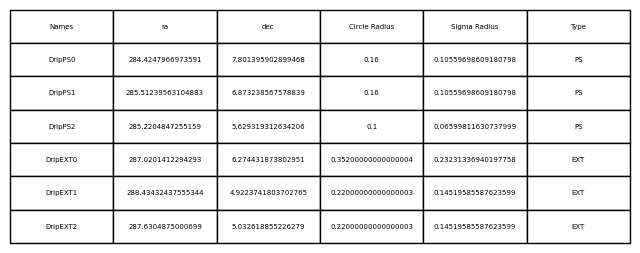

In [282]:
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.show()
plt.close(fig)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
28.8
28.8
18.0
63.36000000000001
39.6
39.6


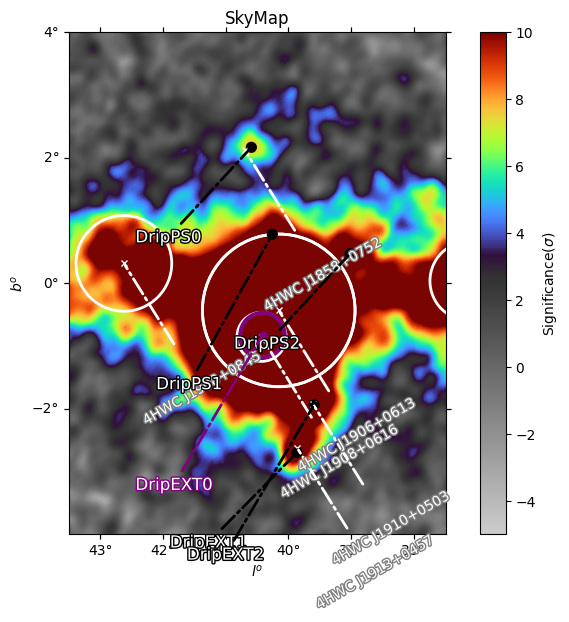

In [283]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    # "ext": filtered_df['Sigma Radius'],
    "ext": filtered_df['Circle Radius'],
    })
name = ['ic443 ps', 'halo ext']
ra = [94.42, 93.67]
dec = [22.35, 22.22]
ext = [0.01, 1.05]
hotspots2 = pd.DataFrame({
    "Name": name, 
    "ra": ra,
    "dec":  dec, 
    "ext": ext,
    })

fig,ax=make_plots(array, wcs, pixel_size,threshold=3, vmin=-5, vmax=10,  coordsys='G',hotspots=None, hotspots2=None, title=f'SkyMap', cmap='ult', labels=['4hawc', '1lhaaaso', '4fagl', 'sanr', 'pulsaar'])

for i in range(len(seed_final)):
    coord2 = SkyCoord(ra=filtered_df['ra'][i]*u.deg, dec=filtered_df['dec'][i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = filtered_df['Circle Radius'][i] / pixel_size
    print(r)
    if i%2 == 0:
        if r > 50:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(-50, -90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(-50, -90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    else:
        if r > 50:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(-50, -150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(-50, -150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    ax.add_patch(c)

for i in range(len(hotspots2)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = 2*ext[i] / pixel_size
    # print(r)
    if i%2 == 0:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    else:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 120), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 160), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    ax.add_patch(c)


if save_pdf:
    pdf.savefig(fig)
    pdf.close()

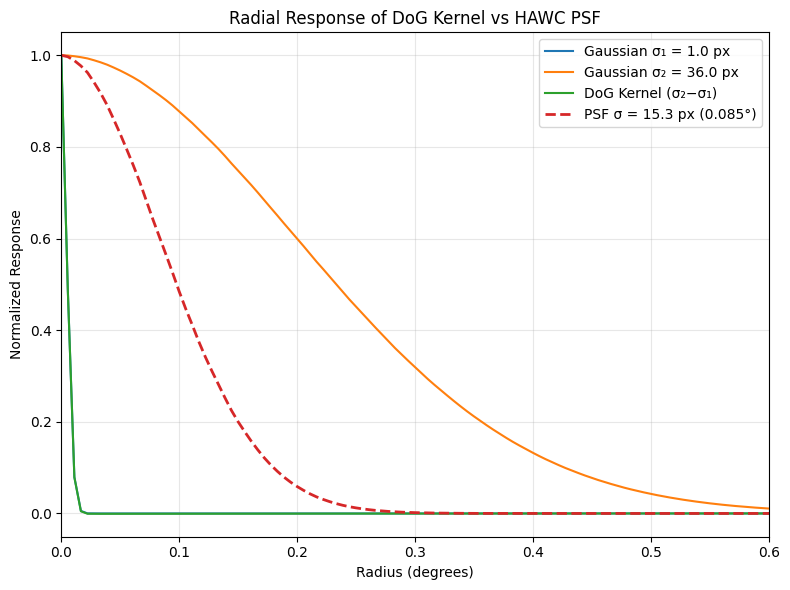

In [251]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def radial_profile(image, center=None):
    y, x = np.indices(image.shape)
    if center is None:
        center = np.array(image.shape) // 2

    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), image.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / np.maximum(nr, 1)
    return radialprofile

# -------------------------------------------------------------
# HAWC PARAMETERS (your actual numbers)
# -------------------------------------------------------------
pixel_size_deg = 0.00555     # degrees per pixel
psf_fwhm_deg   = 0.20        # FWHM degrees

# Convert PSF FWHM → sigma in degrees
psf_sigma_deg = psf_fwhm_deg / 2.355
psf_sigma_px  = psf_sigma_deg / pixel_size_deg

# DoG parameters from your code
sigma1_px = 1.0                            # sigma1 = 1 pixel
sigma2_px = 0.20 / pixel_size_deg          # smear_radius/pixel_size ~ 36.04 px

# -------------------------------------------------------------
# BUILD 2D KERNELS
# -------------------------------------------------------------
size = 600  # large enough to contain wide kernels
center = size // 2
impulse = np.zeros((size, size))
impulse[center, center] = 1.0

# Gaussians
g1  = gaussian_filter(impulse, sigma=sigma1_px)
g2  = gaussian_filter(impulse, sigma=sigma2_px)

# Difference of Gaussians
dog = g1 - g2

# PSF kernel
psf = gaussian_filter(impulse, sigma=psf_sigma_px)

# Radial profiles
r_g1  = radial_profile(g1)
r_g2  = radial_profile(g2)
r_dog = radial_profile(dog)
r_psf = radial_profile(psf)

# Radius in degrees for plotting
r_deg = np.arange(len(r_g1)) * pixel_size_deg

# -------------------------------------------------------------
# PLOT
# -------------------------------------------------------------
plt.figure(figsize=(8,6))

plt.plot(r_deg, r_g1 / np.max(r_g1),      label=f"Gaussian σ₁ = {sigma1_px:.1f} px")
plt.plot(r_deg, r_g2 / np.max(r_g2),      label=f"Gaussian σ₂ = {sigma2_px:.1f} px")
plt.plot(r_deg, r_dog / np.max(np.abs(r_dog)), label="DoG Kernel (σ₂−σ₁)")
plt.plot(r_deg, r_psf / np.max(r_psf),    label=f"PSF σ = {psf_sigma_px:.1f} px ({psf_sigma_deg:.3f}°)", lw=2, ls='--')

plt.xlabel("Radius (degrees)")
plt.ylabel("Normalized Response")
plt.title("Radial Response of DoG Kernel vs HAWC PSF")
plt.grid(alpha=0.3)
plt.xlim(0, 0.6)   # adjust if needed
plt.legend()
plt.tight_layout()
plt.show()


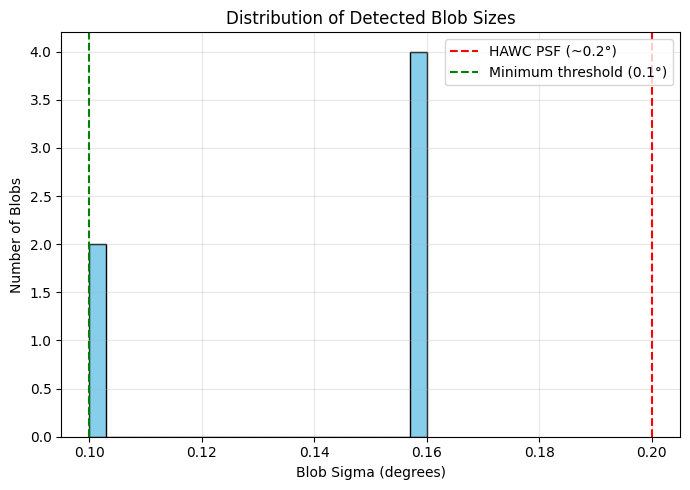

In [252]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import blob_dog

# -------------------------------------------------------------
# Example: run blob detection on DoG image
# -------------------------------------------------------------
# dog_image = difference_of_gaussians(norm_image, sigma1, sigma2)
# Replace with your DoG image

# Example: simulate DoG image (replace with your actual dog_image)
# dog_image = norm_image  # your precomputed DoG image

# -------------------------------------------------------------
# Blob detection parameters (tune to your workflow)
# -------------------------------------------------------------
min_sigma_px = 0.1 / 0.00555      # 0.1 deg / pixel size
max_sigma_px = 0.2 / 0.00555      # 0.2 deg / pixel size (PSF scale)
threshold_val = 0.01               # threshold in DoG units

# Run blob detection
# blobs_dog output: [y, x, sigma]
blobs_dog = blob_dog(dog_image,
                     min_sigma=min_sigma_px,
                     max_sigma=max_sigma_px,
                     threshold=threshold_val,
                     overlap=0.5)

# Extract blob sizes (sigma)
blob_sigmas_px = blobs_dog[:, 2]  # third column is sigma in pixels

# Convert sigma to degrees
pixel_size_deg = 0.00555
blob_sigmas_deg = blob_sigmas_px * pixel_size_deg

# -------------------------------------------------------------
# Plot histogram of blob sizes
# -------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.hist(blob_sigmas_deg, bins=20, color='skyblue', edgecolor='k')
plt.axvline(0.2, color='r', linestyle='--', label='HAWC PSF (~0.2°)')
plt.axvline(0.1, color='g', linestyle='--', label='Minimum threshold (0.1°)')

plt.xlabel("Blob Sigma (degrees)")
plt.ylabel("Number of Blobs")
plt.title("Distribution of Detected Blob Sizes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [69]:
counterparts=get_simbad_counterparts(filtered_df, ra_center, dec_center, filename)

    Name   snr  lmxb  hmxb          pulsar   sfr
0  Drip0  None  None  None            None  None
1  Drip1  None  None  None            None  None
2  Drip2  None  None  None  [PSR B0611+22]  None
3  Drip3  None  None  None            None  None
